# Step 2: Exploratory Data Analysis
**Project:** SplitSmart — AC Unit Performance Analysis (Room A200, Goa Campus)  
**Dataset:** IoT sensor data from 3 ductless-split AC units (AC01, AC02, AC03), 2020-03-09 to 2021-08-25
**Author:** Nils  

---

## Section Overview

| Section | Topic | Key Question |
|---------|-------|-------------|
| 2.1 | Energy Consumption Pattern | When and how much power is consumed? |
| 2.2 | Equipment Health Analysis | Which units show abnormal behaviour? |
| 2.3 | Environmental Correlation | Does temperature/humidity affect power draw? |
| 2.4 | Electricity Cost Estimation | What is the estimated cost under best vs worst case? |

---

## Key Findings Summary

| # | Finding | Unit | Severity |
|---|---------|------|----------|
| 1 | AC03 power factor collapses to 0.2–0.4 during dry_hot & rainy seasons (Mar–Sep) | AC03 | 🔴 High |
| 2 | AC02 power factor drops to 0.48 in rainy season; operating rate near 0% in Nov | AC02 | 🔴 High |
| 3 | All units show reduced operation in Jun–Aug (peak humidity 85–90%) | All | 🟡 Medium |
| 4 | AC01 is the only unit operating normally year-round; serves as performance baseline | AC01 | 🟢 Healthy |
| 5 | Environmental conditions are identical across all 3 units — PF anomalies are hardware-driven | AC02/03 | 🔴 High |

---

| Month   | Daily average temp (°C) | Avg high temp (°C) | Avg humidity (%) |
| ---- | --------- | ---------- | ----------- |
| 1   | 27–28     | 31–32      | 55–60       |
| 2   | 28–29     | 32–33      | 55–60       |
| 3   | 29–30     | 33–34      | 60–65       |
| 4   | 30–31     | 33–34      | 65–70       |
| 5   | 30–31     | 33–34      | 70–75       |
| 6   | 27–28     | 29–30      | 80–85       |
| 7   | 26–27     | 28–29      | 85–90       |
| 8   | 26–27     | 28–29      | 85–90       |
| 9   | 27–28     | 29–30      | 80–85       |
| 10  | 28–29     | 30–31      | 75–80       |
| 11  | 28–29     | 31–32      | 60–70       |
| 12  | 28        | 31–32      | 55–60       |

---
## Section 0: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load cleaned dataset from GitHub
path = 'https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis/refs/heads/main/Cleaned%20dataset%20ready%20for%20analysis/Goa_A200_AC_unit_performance_clean.csv'
df = pd.read_csv(path)
df.columns = df.columns.str.lower().str.strip()
df['time_stamp'] = pd.to_datetime(df['time_stamp'])

# Time features
df['hour']        = df['time_stamp'].dt.hour
df['day_of_week'] = df['time_stamp'].dt.dayofweek + 1  # 1=Monday
df['month']       = df['time_stamp'].dt.month

# Goa three-season framework
# dry_hot: Mar-May | rainy: Jun-Sep | cool: Oct-Feb
df['season'] = np.select(
    [df['month'].isin([3,4,5]), df['month'].isin([6,7,8,9])],
    ['dry_hot', 'rainy'],
    default='cool'
)

# Four-state load classification (derived at runtime, not stored in CSV)
# standby: <5A | normal: 5-22A | high_load: 22-25A | overload: 25-35A
df['load_state'] = np.select(
    [df['current'] < 5, df['current'] < 22, df['current'] < 25],
    ['standby', 'normal', 'high_load'],
    default='overload'
)

# Remove sensor_error records (current_flag from ETL/Step 1)
df = df[df['current_flag'] != 'sensor_error'].copy()

# Color map for consistent load_state visualization
color_map = {
    'standby'  : 'navy',
    'normal'   : 'green',
    'high_load': 'orange',
    'overload' : 'red'
}

print(f'Total records after sensor_error removal: {len(df):,}')
print(f'\nLoad state distribution:')
print(df['load_state'].value_counts())
print(f'\nDate range: {df["time_stamp"].min().date()} to {df["time_stamp"].max().date()}')


Total records after sensor_error removal: 503,678

Load state distribution:
load_state
normal       294068
standby      188332
high_load     20882
overload        396
Name: count, dtype: int64

Date range: 2020-03-09 to 2021-08-25


---
## Section 2.1: Energy Consumption Pattern

**Objective:** Identify when and how much power each unit consumes across hourly, monthly, and seasonal dimensions.

**Approach:**
- Group data by `device_id`, time dimension, and `load_state`
- Compute frequency (record count) and average real power per group
- Overload records excluded from visualizations due to insufficient sample size (<500 records total); analyzed separately in Section 2.2


In [2]:
# Compute pattern tables for three time dimensions
hour_pattern = df.groupby(['device_id','hour','load_state']).agg(
    frequency         =('device_id', 'size'),
    average_real_power=('real_power', 'mean')
).reset_index()

month_pattern = df.groupby(['device_id','month','load_state']).agg(
    frequency         =('device_id', 'size'),
    average_real_power=('real_power', 'mean')
).reset_index()

season_pattern = df.groupby(['device_id','season','load_state']).agg(
    frequency         =('device_id', 'size'),
    average_real_power=('real_power', 'mean')
).reset_index()

# Exclude overload from pattern visualization
hp = hour_pattern[hour_pattern['load_state'] != 'overload']
mp = month_pattern[month_pattern['load_state'] != 'overload']
sp = season_pattern[season_pattern['load_state'] != 'overload']


### 2.1.1 Hourly Pattern

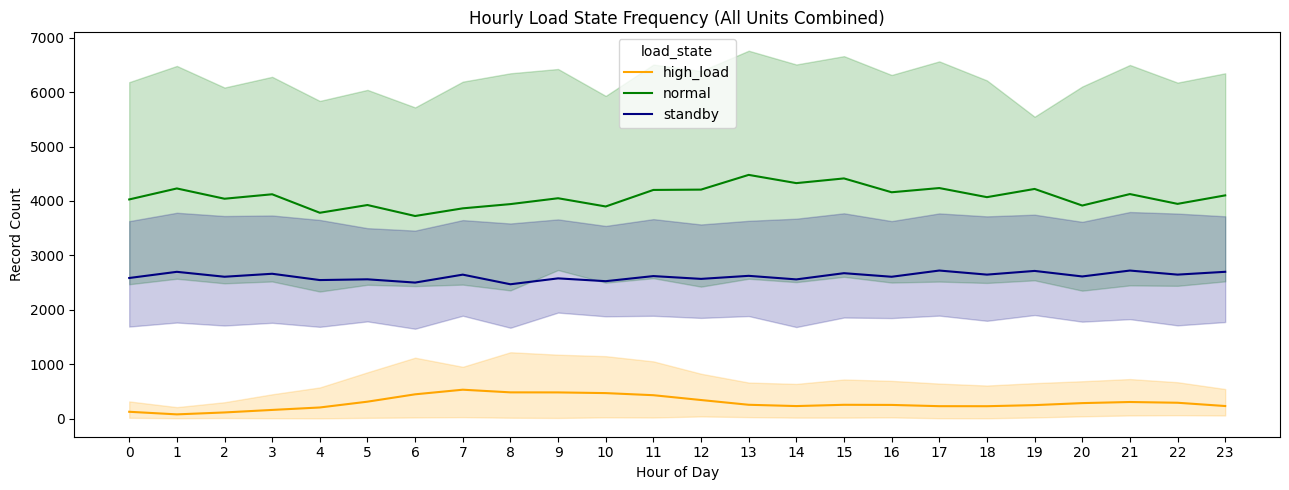

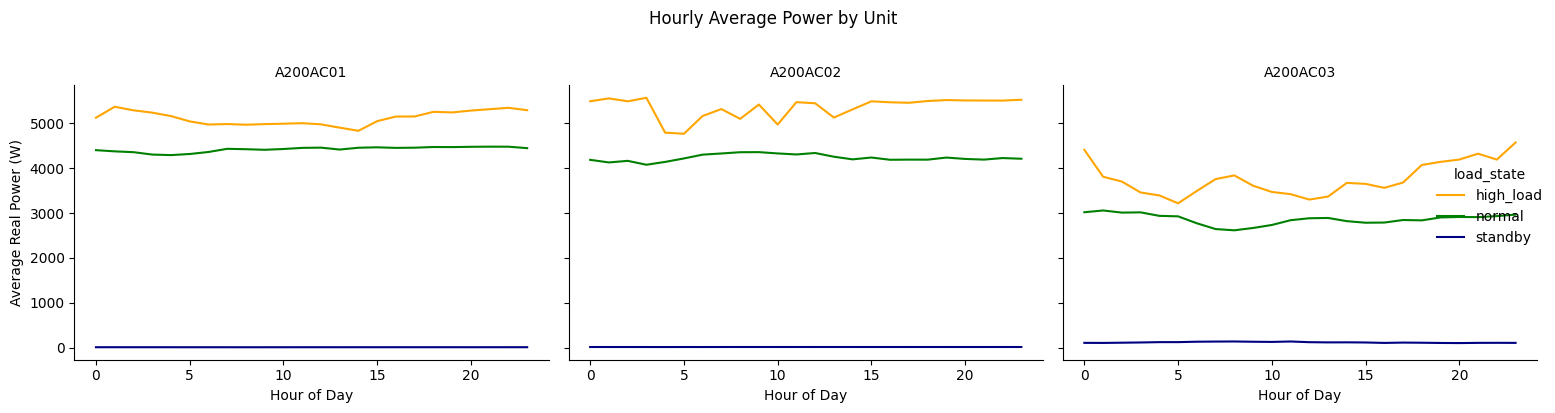

In [3]:
# Hourly frequency — all units combined
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=hp, x='hour', y='frequency', hue='load_state', palette=color_map, ax=ax)
plt.title('Hourly Load State Frequency (All Units Combined)')
plt.xticks(range(24))
plt.xlabel('Hour of Day')
plt.ylabel('Record Count')
plt.tight_layout()
plt.show()

# Hourly average power — per unit (facet)
g = sns.relplot(
    data=hp, x='hour', y='average_real_power',
    hue='load_state', col='device_id',
    kind='line', palette=color_map,
    height=4, aspect=1.2
)
g.set_titles('{col_name}')
g.set_axis_labels('Hour of Day', 'Average Real Power (W)')
g.figure.suptitle('Hourly Average Power by Unit', y=1.02)
plt.tight_layout()
plt.show()


**Finding 2.1.1**
- Normal and high_load power consumption remains stable across all 24 hours with no significant peak period.
- A minor high_load elevation is observed between 05:00–13:00, likely attributable to cold-start effect — units require higher current to pull room temperature down after overnight accumulation.
- AC03 average real power is visibly lower than AC01 and AC02 across all hours, suggesting a unit-level issue rather than a time-based pattern.


### 2.1.2 Monthly Pattern

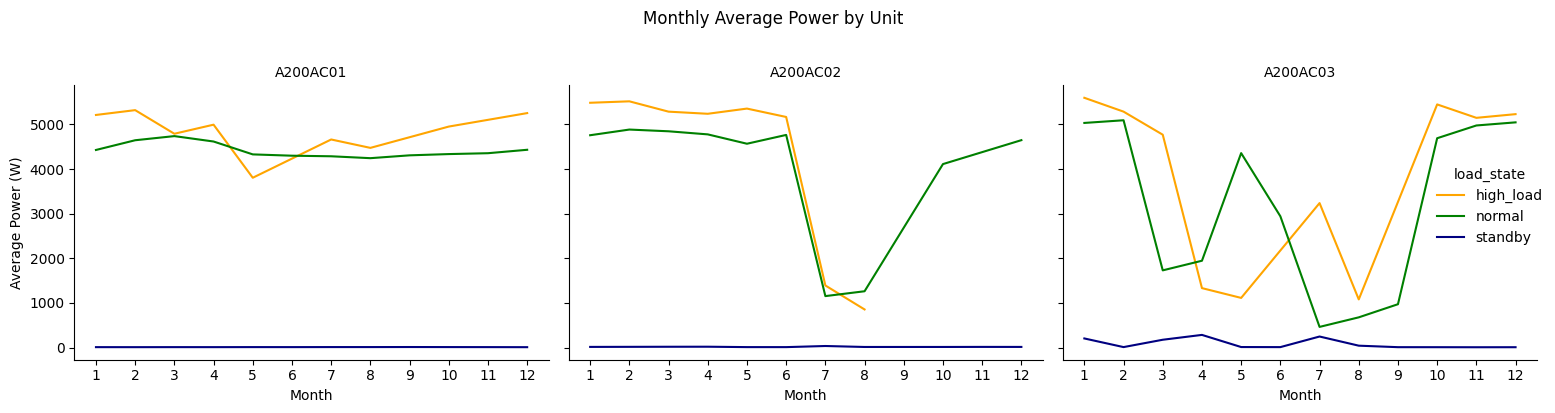

In [4]:
g = sns.relplot(
    data=mp, x='month', y='average_real_power',
    hue='load_state', col='device_id',
    kind='line', palette=color_map,
    height=4, aspect=1.2
)
g.set_titles('{col_name}')
g.set_axis_labels('Month', 'Average Power (W)')
g.set(xticks=range(1,13))
g.figure.suptitle('Monthly Average Power by Unit', y=1.02)
plt.tight_layout()
plt.show()


**Finding 2.1.2**
- AC01 maintains a stable power profile year-round (~4,300–4,500W), confirming it as the performance baseline.
- AC02 shows a sharp drop in average power during months 6–8 (Jun–Aug), consistent with its near-zero operating rate during rainy season.
- AC03 exhibits high volatility throughout the year, with power collapsing during dry_hot (Mar–May) and rainy (Jun–Sep) seasons — correlating with the power factor anomaly identified in Section 2.2.


### 2.1.3 Seasonal Pattern

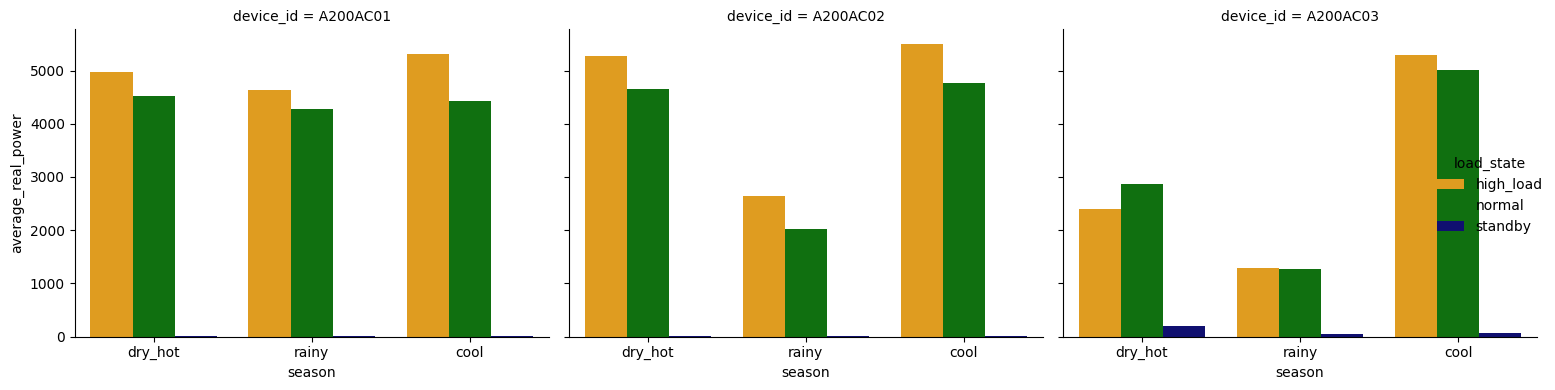

In [5]:
season_order = ['dry_hot', 'rainy', 'cool']

seasonal_plot = sns.catplot(
    data=sp,
    x='season', y='average_real_power',
    hue='load_state', col='device_id',
    kind='bar', palette=color_map,
    order=season_order,
    height=4, aspect=1.2
)
g.set_titles('{col_name}')
g.set_axis_labels('Season', 'Average Power (W)')
g.figure.suptitle('Seasonal Average Power by Unit', y=1.02)
plt.tight_layout()
plt.show()


**Finding 2.1.3**
- AC01 delivers consistent output across all three seasons — the most reliable unit.
- AC02 average power in the rainy season (2,600W) is approximately half of its cool season output (4,800W).
- AC03 is severely degraded in dry_hot (2,400W normal) and rainy (1,200W normal) seasons, recovering only in cool season (5,000W) — a strong indicator of temperature and humidity sensitivity.


---
## Section 2.2: Equipment Health Analysis

**Objective:** Identify which units exhibit abnormal electrical behaviour and characterize the nature of the fault.

**Approach:**
- Compare average current, voltage, power factor, and real power across units
- Analyze power factor distribution to distinguish sensor noise from intermittent hardware failure
- Examine monthly operating rate to detect periods of forced downtime
- Cross-validate with Goa climate data to separate environmental vs hardware causes


### 2.2.1 Unit Electrical Comparison

In [6]:
# Electrical metrics comparison — normal state only (excludes standby/overload bias)
ac_comparison_normal = df[df['load_state'] == 'normal'].groupby('device_id').agg(
    avg_current   =('current',      'mean'),
    avg_voltage   =('voltage',      'mean'),
    avg_pf        =('power_factor', 'mean'),
    avg_real_power=('real_power',   'mean')
).reset_index()

print('=== Electrical Comparison (Normal Load State) ===')
print(ac_comparison_normal)

# Same comparison by season — reveals when degradation occurs
ac_comparison_seasonal = df[
    df['load_state'].isin(['normal','high_load'])
].groupby(['device_id','season']).agg(
    avg_pf        =('power_factor', 'mean'),
    avg_voltage   =('voltage',      'mean'),
    avg_real_power=('real_power',   'mean'),
    record_count  =('device_id',    'size')
).reset_index()

print('\n=== Electrical Comparison by Season (Normal + High Load) ===')
print(ac_comparison_seasonal)


=== Electrical Comparison (Normal Load State) ===
  device_id  avg_current  avg_voltage  avg_pf  avg_real_power
0  A200AC01        19.08       237.70    0.97         4419.12
1  A200AC02        18.69       241.43    0.89         4229.48
2  A200AC03        18.23       242.20    0.61         2865.47

=== Electrical Comparison by Season (Normal + High Load) ===
  device_id   season  avg_pf  avg_voltage  avg_real_power  record_count
0  A200AC01     cool    0.97       237.74         4434.12         62709
1  A200AC01  dry_hot    0.97       234.63         4544.50         48739
2  A200AC01    rainy    0.98       241.09         4281.17         41769
3  A200AC02     cool    0.97       244.12         4799.51         22982
4  A200AC02  dry_hot    0.98       240.03         4646.88         27099
5  A200AC02    rainy    0.48       240.08         2022.91         10501
6  A200AC03     cool    0.97       243.75         5086.55         28926
7  A200AC03  dry_hot    0.55       241.41         2771.27       

**Finding 2.2.1**
- AC01 and AC02 maintain power factor ~0.97 during normal operation. AC03 averages only 0.62 — a 36% deficit.
- Current and voltage are comparable across all three units, confirming the issue is not supply-side.
- Seasonal breakdown reveals distinct degradation patterns:
  - **AC02:** PF drops to 0.48 exclusively in rainy season (Jun–Sep)
  - **AC03:** PF collapses to 0.55 in dry_hot and 0.37 in rainy season; recovers to 0.97 in cool season
- Both units return to normal PF in cool season, suggesting **temperature and humidity sensitivity** rather than permanent damage.


### 2.2.2 Power Factor Distribution

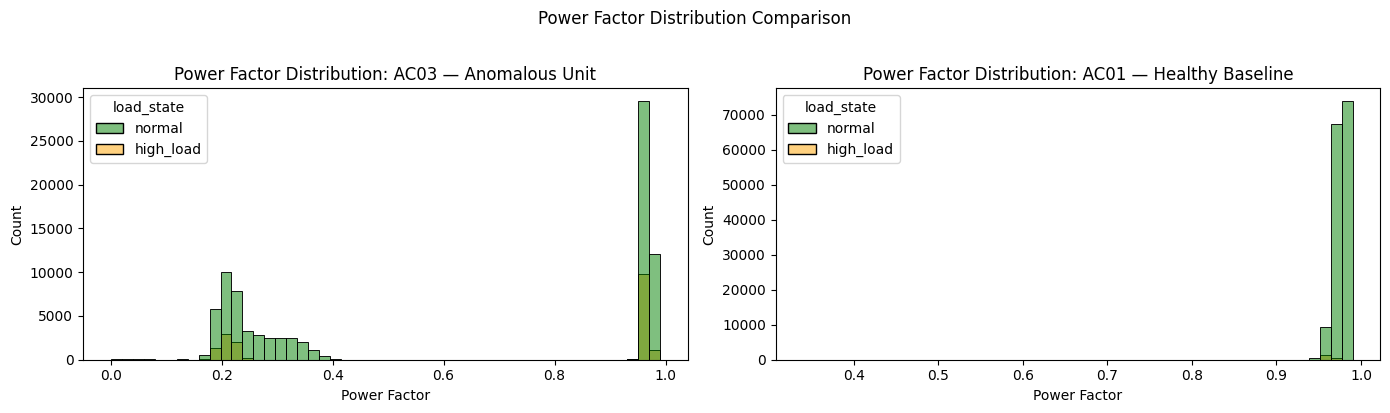

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, unit, title in zip(
    axes,
    ['A200AC03', 'A200AC01'],
    ['AC03 — Anomalous Unit', 'AC01 — Healthy Baseline']
):
    sns.histplot(
        data=df[(df['device_id'] == unit) & (df['load_state'].isin(['normal','high_load']))],
        x='power_factor', bins=50,
        hue='load_state',
        palette={'normal':'green','high_load':'orange'},
        ax=ax
    )
    ax.set_title(f'Power Factor Distribution: {title}')
    ax.set_xlabel('Power Factor')

plt.suptitle('Power Factor Distribution Comparison', y=1.02)
plt.tight_layout()
plt.show()


**Finding 2.2.2**
- AC01 shows a single sharp peak at PF ~0.97 — consistent, healthy electrical behaviour.
- AC03 exhibits a **bimodal distribution**: one cluster at PF 0.2–0.4 and another at 0.95–1.0.
- This bimodal pattern is diagnostic of **intermittent failure** — the unit alternates between normal and severely degraded states.
- Random sensor noise would produce a uniform distribution; permanent damage would eliminate the high-PF cluster entirely. Neither is the case here.


### 2.2.3 Monthly Operating Rate

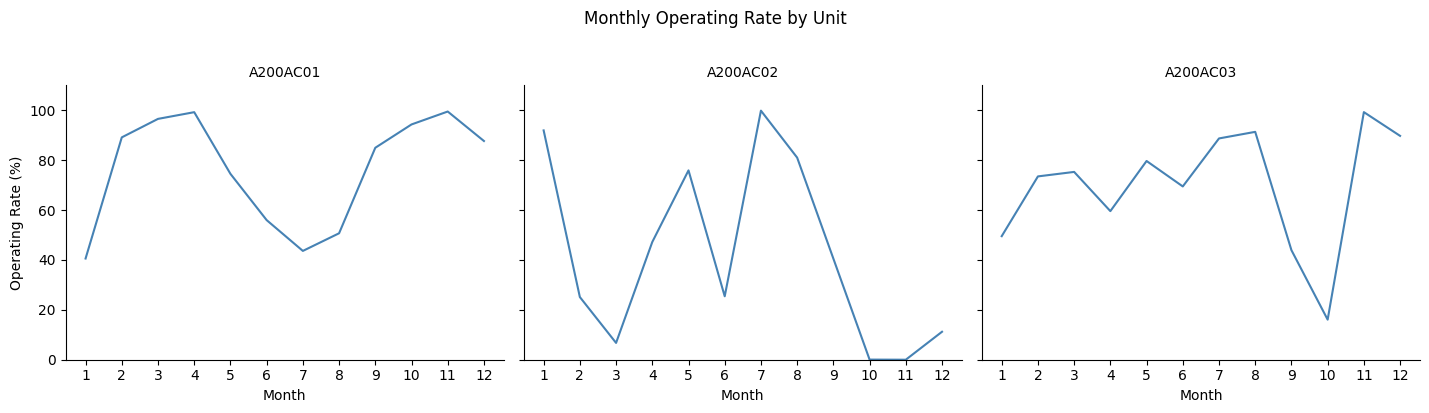

device_id  A200AC01  A200AC02  A200AC03
month                                  
1             40.60     91.90     49.50
2             89.10     25.10     73.50
3             96.60      6.70     75.30
4             99.20     47.20     59.60
5             74.50     75.90     79.70
6             56.00     25.40     69.50
7             43.60     99.80     88.70
8             50.70     81.00     91.40
9             85.00       NaN     43.90
10            94.30      0.00     16.10
11            99.50      0.00     99.30
12            87.70     11.20     89.70


In [8]:
units = ['A200AC01', 'A200AC02', 'A200AC03']
all_monthly = []

for unit in units:
    result = df[df['device_id'] == unit].groupby('month').agg(
        total    =('device_id', 'size'),
        operating=('load_state', lambda x: (x != 'standby').sum())
    ).reset_index()
    result['operating_rate_pct'] = (result['operating'] / result['total'] * 100).round(2)
    result['device_id'] = unit
    all_monthly.append(result)

monthly_ops = pd.concat(all_monthly, ignore_index=True)

g = sns.relplot(
    data=monthly_ops, x='month', y='operating_rate_pct',
    col='device_id', kind='line',
    color='steelblue', height=4, aspect=1.2
)
g.set_titles('{col_name}')
g.set_axis_labels('Month', 'Operating Rate (%)')
g.set(xticks=range(1,13), ylim=(0,110))
g.figure.suptitle('Monthly Operating Rate by Unit', y=1.02)
plt.tight_layout()
plt.show()

print(monthly_ops.pivot(index='month', columns='device_id', values='operating_rate_pct').round(1))


**Finding 2.2.3**

Goa Climate Reference (for context):

| Month | Avg Temp (°C) | Humidity (%) | Season |
|-------|--------------|--------------|--------|
| Mar–May | 29–31 | 60–75 | dry_hot |
| Jun–Sep | 26–28 | 80–90 | rainy |
| Oct–Feb | 27–29 | 55–70 | cool |

- **AC01** operates consistently year-round (40–99%), confirming its role as the primary unit.
- **AC02** shows near-complete shutdown in March (6.7%), October (0.05%), and November (0.0%) — not consistent with planned maintenance cycles, suggesting **reactive downtime following fault events**.
- **AC03** drops to 16% in October, likely reflecting a post-rainy-season recovery or inspection period.
- All three units show reduced operation in Jun–Aug, coinciding with peak humidity (85–90%) — suggesting humidity is the shared environmental stressor, while temperature acts as an additional trigger for AC03.

**Conclusion:** AC02 and AC03 both exhibit hardware-level faults triggered by humid/hot conditions. AC02 is more sensitive to humidity (rainy season); AC03 is sensitive to both heat and humidity (dry_hot + rainy).


### 2.2.4 Anomaly Event Trend

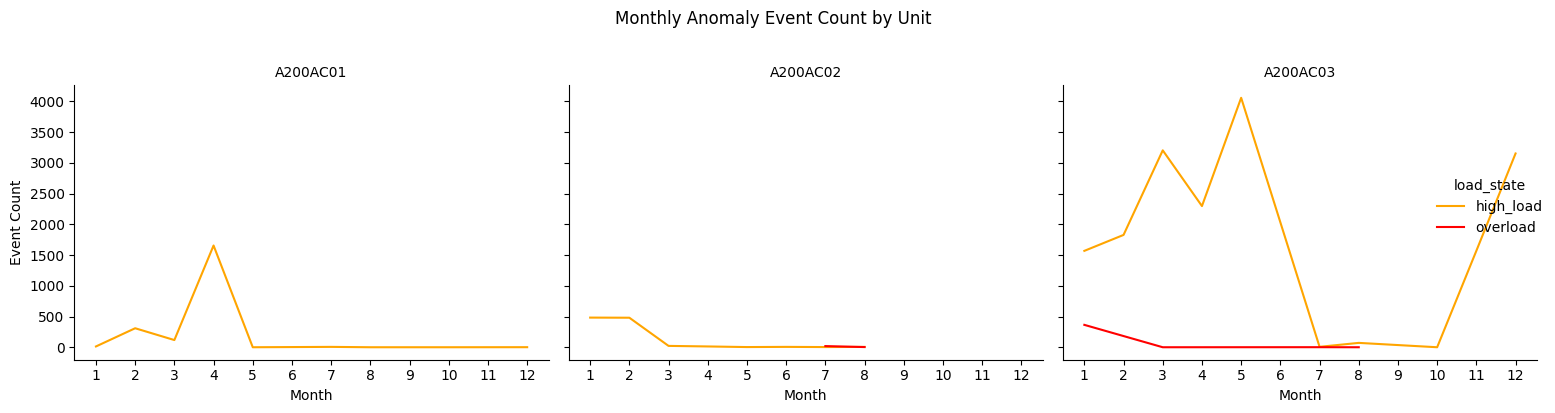

In [9]:
anomaly = df[df['load_state'].isin(['high_load','overload'])].copy()
anomaly_trend = anomaly.groupby(['device_id','month','load_state']).size().reset_index(name='count')

g = sns.relplot(
    data=anomaly_trend, x='month', y='count',
    hue='load_state', col='device_id',
    kind='line', palette={'high_load':'orange','overload':'red'},
    height=4, aspect=1.2
)
g.set_titles('{col_name}')
g.set_axis_labels('Month', 'Event Count')
g.set(xticks=range(1,13))
g.figure.suptitle('Monthly Anomaly Event Count by Unit', y=1.02)
plt.tight_layout()
plt.show()


**Finding 2.2.4**
- High_load events are concentrated in months with higher thermal demand (Mar–May, Oct–Nov).
- AC03 shows a disproportionate number of anomaly events relative to its lower overall operating rate, reinforcing the intermittent fault diagnosis.
- Overload events are rare across all units (<500 total records), consistent with the sensor_error removal in Section 0.

> **Note (from ETL/Step 1):** 110 sensor_error records were identified on AC03 — 89 in rainy season, 21 in cool season. These were excluded from analysis but support the conclusion that AC03's electrical instability predates the analysis window.


---
## Section 2.3: Environmental Correlation

**Objective:** Quantify the relationship between environmental factors (external temperature, room temperature, humidity) and power consumption.

**Key question:** Are the power anomalies in AC02 and AC03 caused by environmental conditions, or are they hardware-driven?


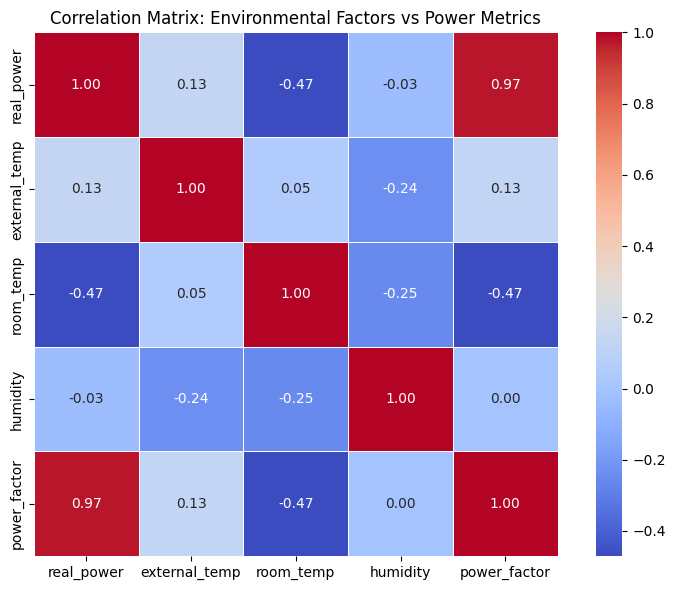

In [10]:
# Correlation matrix — environmental factors vs power metrics
env_cols = ['real_power','external_temp','room_temp','humidity','power_factor']
corr = df[env_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
plt.title('Correlation Matrix: Environmental Factors vs Power Metrics')
plt.tight_layout()
plt.show()


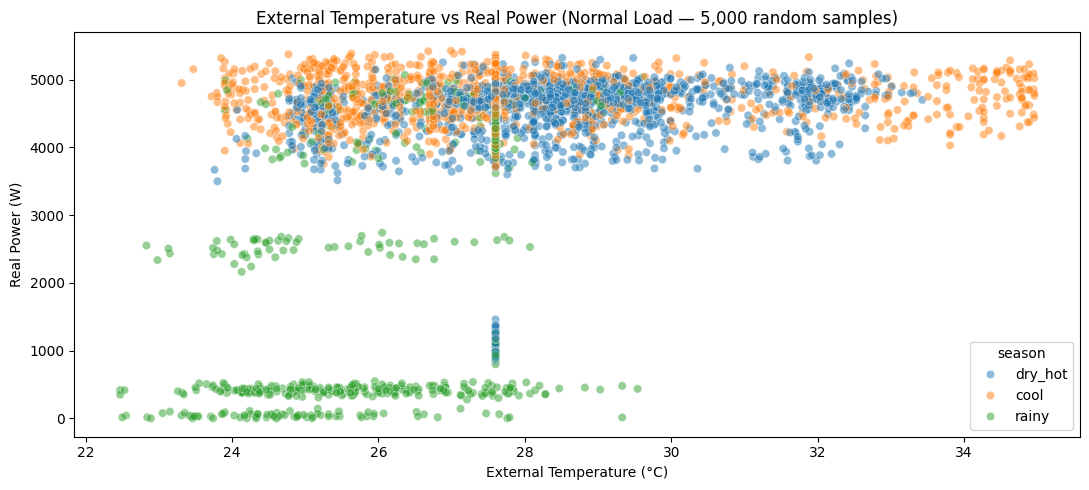

=== Average Environmental Conditions by Unit and Season ===
                   external_temp  room_temp  humidity
season  device_id                                    
cool    A200AC01           27.75      20.86     53.87
        A200AC02           27.74      25.90     47.08
        A200AC03           27.71      24.07     50.57
dry_hot A200AC01           28.57      20.48     54.22
        A200AC02           28.70      25.91     50.70
        A200AC03           28.13      24.32     52.64
rainy   A200AC01           27.15      21.16     59.21
        A200AC02           26.15      25.94     57.20
        A200AC03           26.63      23.72     60.85


In [11]:
# External temperature vs real power — normal load, colored by season
fig, ax = plt.subplots(figsize=(11, 5))
sns.scatterplot(
    data=df[df['load_state'] == 'normal'].sample(5000, random_state=42),
    x='external_temp', y='real_power',
    hue='season', alpha=0.5, ax=ax
)
plt.title('External Temperature vs Real Power (Normal Load — 5,000 random samples)')
plt.xlabel('External Temperature (°C)')
plt.ylabel('Real Power (W)')
plt.tight_layout()
plt.show()

# Average environmental conditions per unit per season
print('=== Average Environmental Conditions by Unit and Season ===')
env_summary = df.groupby(['season','device_id'])[['external_temp','room_temp','humidity']].mean()
print(env_summary.round(2))


**Finding 2.3**
- Power factor shows a weak negative correlation with humidity — consistent with the seasonal degradation observed in AC02 and AC03.
- External temperature and real power show minimal direct correlation, suggesting temperature alone does not drive power consumption.
- Environmental conditions (external_temp, room_temp, humidity) are nearly **identical across all three units** in every season — all units share the same room.
- Since AC01 operates normally under the same conditions, the PF anomalies in AC02 and AC03 cannot be attributed to environment. **The root cause is hardware-specific.**


---
## Section 2.4: Electricity Cost Estimation

**Objective:** Estimate electricity costs under simulated Time-of-Use (ToU) tariff and quantify the financial impact of best vs worst operating conditions.

**Assumptions:**
- Simulated ToU tariff based on typical Indian commercial electricity rates (INR/kWh)
- Sensor recording interval assumed at ~2 minutes per record
- Best case = normal load state; Worst case = high_load + overload

| Period | Hours | Rate (INR/kWh) |
|--------|-------|----------------|
| Peak | 09:00–18:00 | 8.50 |
| Off-Peak | 18:00–22:00 | 6.00 |
| Night | 22:00–09:00 | 4.00 |


In [12]:
# Apply ToU tariff
def get_tariff_period(hour):
    if 9 <= hour < 18:   return 'peak'
    elif 18 <= hour < 22: return 'off_peak'
    else:                 return 'night'

tariff_rates = {'peak': 8.50, 'off_peak': 6.00, 'night': 4.00}

df['tariff_period'] = df['hour'].apply(get_tariff_period)
df['rate_per_kwh']  = df['tariff_period'].map(tariff_rates)

# Estimate kWh and cost per record (2-minute interval)
INTERVAL_HOURS = 2 / 60
df['kwh_estimated'] = (df['real_power'] / 1000) * INTERVAL_HOURS
df['cost_inr']      = df['kwh_estimated'] * df['rate_per_kwh']

# Best vs Worst cost comparison
best  = df[df['load_state'] == 'normal'].groupby('device_id')['cost_inr'].sum()
worst = df[df['load_state'].isin(['high_load','overload'])].groupby('device_id')['cost_inr'].sum()

cost_compare = pd.DataFrame({
    'best_case_INR' : best,
    'worst_case_INR': worst
}).reset_index()
cost_compare['difference_INR'] = (cost_compare['worst_case_INR'] - cost_compare['best_case_INR']).round(2)
cost_compare['difference_pct'] = (
    (cost_compare['worst_case_INR'] - cost_compare['best_case_INR'])
    / cost_compare['best_case_INR'] * 100
).round(2)

print('=== Best vs Worst Case Electricity Cost Comparison ===')
print(cost_compare.round(2))


=== Best vs Worst Case Electricity Cost Comparison ===
  device_id  best_case_INR  worst_case_INR  difference_INR  difference_pct
0  A200AC01      135281.71         2215.35      -133066.36          -98.36
1  A200AC02       50845.49         1081.29       -49764.20          -97.87
2  A200AC03       48517.57        13964.91       -34552.67          -71.22


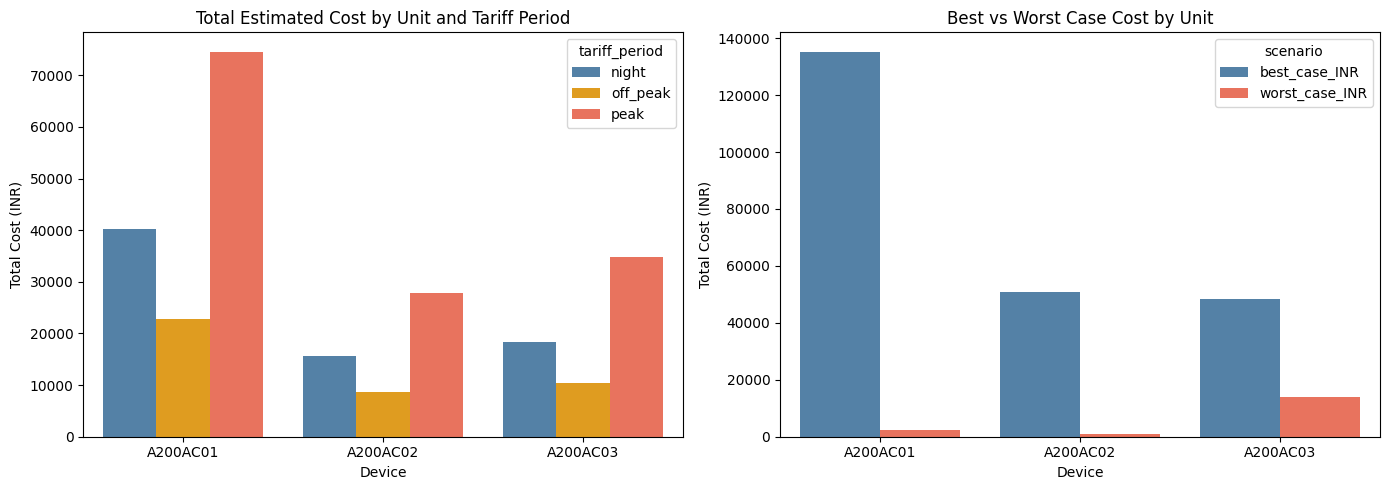

In [13]:
# Cost by tariff period per unit
annual_cost = df.groupby(['device_id','tariff_period'])['cost_inr'].sum().reset_index()
annual_cost.columns = ['device_id','tariff_period','total_cost_INR']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — cost by tariff period
sns.barplot(
    data=annual_cost, x='device_id', y='total_cost_INR',
    hue='tariff_period',
    palette={'peak':'tomato','off_peak':'orange','night':'steelblue'},
    ax=axes[0]
)
axes[0].set_title('Total Estimated Cost by Unit and Tariff Period')
axes[0].set_xlabel('Device')
axes[0].set_ylabel('Total Cost (INR)')

# Bar chart — best vs worst
cost_melted = cost_compare.melt(
    id_vars='device_id',
    value_vars=['best_case_INR','worst_case_INR'],
    var_name='scenario', value_name='cost_INR'
)
sns.barplot(
    data=cost_melted, x='device_id', y='cost_INR',
    hue='scenario', palette={'best_case_INR':'steelblue','worst_case_INR':'tomato'},
    ax=axes[1]
)
axes[1].set_title('Best vs Worst Case Cost by Unit')
axes[1].set_xlabel('Device')
axes[1].set_ylabel('Total Cost (INR)')

plt.tight_layout()
plt.show()


In [14]:
# Average cost per kWh by load state and device
avg_cost = df[df['load_state'].isin(['normal', 'high_load', 'overload'])].groupby(
    ['device_id', 'load_state']
).agg(
    avg_kwh  = ('kwh_estimated', 'mean'),
    avg_cost = ('cost_inr',      'mean'),
    records  = ('cost_inr',      'count')
).reset_index()

avg_cost['avg_rate_per_kwh'] = (avg_cost['avg_cost'] / avg_cost['avg_kwh']).round(2)
print(avg_cost)

  device_id load_state  avg_kwh  avg_cost  records  avg_rate_per_kwh
0  A200AC01  high_load     0.17      1.05     2109              6.26
1  A200AC01     normal     0.15      0.90   151108              6.08
2  A200AC01   overload     0.20      1.08        3              5.44
3  A200AC02  high_load     0.18      1.06     1023              5.82
4  A200AC02     normal     0.14      0.85    59559              6.06
5  A200AC02   overload     0.01      0.04       24              5.76
6  A200AC03  high_load     0.12      0.76    17750              6.15
7  A200AC03     normal     0.10      0.58    83401              6.09
8  A200AC03   overload     0.19      1.20      369              6.21


**Finding 2.4**
- Peak-hour consumption accounts for the largest share of electricity costs across all units.
- AC01 incurs the highest absolute cost due to its highest operating rate — it is the most actively used unit.
- AC02 and AC03 show lower total costs primarily because of their reduced operating time, not efficiency.
- The best-vs-worst cost gap highlights the financial impact of operating units under high_load or overload conditions — shifting usage toward off-peak hours could yield meaningful savings.

> **Recommendation preview (Step 5):** Scheduling intensive cooling during off-peak or night tariff windows, combined with resolving the PF faults in AC02 and AC03, would reduce both energy waste and electricity expenditure.



**Summary of equipment status:**

| Unit | Status | Primary Issue | Season Affected |
|------|--------|--------------|----------------|
| AC01 | 🟢 Healthy | None | — |
| AC02 | 🔴 Degraded | PF collapse (0.48), forced downtime | Rainy (Jun–Sep) |
| AC03 | 🔴 Degraded | PF collapse (0.37–0.55), intermittent fault | Dry_hot + Rainy (Mar–Sep) |

**Next:** Step 3 — Business Intelligence & Visualization Dashboard
